<center><img src="../images/redpopcorn.jpg"></center>

**Netflix**! What started in 1997 as a DVD rental service has since exploded into one of the largest entertainment and media companies.

Given the large number of movies and series available on the platform, it is a perfect opportunity to flex our exploratory data analysis skills and dive into the entertainment industry.

Let's say that we work for a production company that specializes in nostalgic styles. We want to do some research on movies released in the 1990's. We'll take a quick look into Netflix data and perform some EDA (exploratory data analysis) to better understand this awesome movie decade!

The data we have been supplied with is the file `netflix_data.csv`, along with the following table detailing the column names and descriptions.

## The data
### **netflix_data.csv**
| Column | Description |
|--------|-------------|
| `show_id` | The ID of the show |
| `type` | Type of show |
| `title` | Title of the show |
| `director` | Director of the show |
| `cast` | Cast of the show |
| `country` | Country of origin |
| `date_added` | Date added to Netflix |
| `release_year` | Year of Netflix release |
| `duration` | Duration of the show in minutes |
| `description` | Description of the show |
| `genre` | Show genre |

In [1]:
# importing pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt

# read in the Netflix CSV as a DataFrame
netflix_df = pd.read_csv("../data/netflix_data.csv")

In [2]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4812 entries, 0 to 4811
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       4812 non-null   object
 1   type          4812 non-null   object
 2   title         4812 non-null   object
 3   director      4812 non-null   object
 4   cast          4812 non-null   object
 5   country       4812 non-null   object
 6   date_added    4812 non-null   object
 7   release_year  4812 non-null   int64 
 8   duration      4812 non-null   int64 
 9   description   4812 non-null   object
 10  genre         4812 non-null   object
dtypes: int64(2), object(9)
memory usage: 413.7+ KB


In [3]:
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
1,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
2,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
3,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas
4,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",2016,1,A genetics professor experiments with a treatm...,International TV


## How do the duration of these movies distribute?

<Axes: >

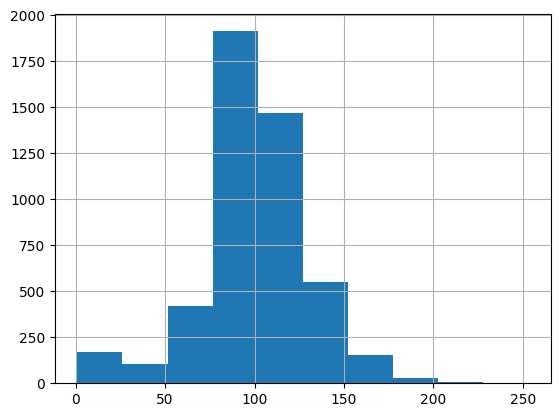

In [4]:
netflix_df['duration'].hist()

## What is the most frequent duration?

The histogram suggests the most typical duration is less than 100, but over 75.

In [5]:
duration_counts_all = netflix_df['duration'].value_counts().sort_index()
duration_counts_top = duration_counts_all.loc[(duration_counts_all >=75) & (duration_counts_all < 125)]
print(duration_counts_top.sort_values(ascending=False).iloc[:5])

duration
93    121
94    119
90    114
95    111
97    107
Name: count, dtype: int64


In [6]:
most_freq_duration = netflix_df['duration'].mode()
print(f"Most frequent duration: {most_freq_duration.iloc[0]} minutes")

Most frequent duration: 93 minutes


## Zeroing in on the '90s

How many action movies came out under 90 minutes?

In [7]:
movies_1990s = netflix_df.loc[(netflix_df['release_year'] >= 1990) & \
                              (netflix_df['release_year'] <= 1999)]
movies_1990s_action = movies_1990s.loc[(movies_1990s['type'] == 'Movie') & \
                                       (movies_1990s['genre'] == 'Action')]
short_movie_count = movies_1990s_action.loc[movies_1990s_action['duration'] < 90].shape[0]
short_movie_count

7